In [12]:
# Import required modules
import sys
sys.path.append('../src')
from signalgen.signal_generator import SignalConfig, SignalGenerator
import matplotlib.pyplot as plt
import numpy as np

# Scenario 1: 1 main source
config_main_only = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96],  # Angles for each source
    use_full_bandwidth=True
)

# Scenario 2: 1 main source + 1 interference
config_main_1_interference = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=2,  # Number of sources
    frequencies=[100, 200],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96, 5],  # Angles for main signal and interference
    sir_db=[0],  # Signal-to-interference ratio
    use_full_bandwidth=True
)

# Scenario 3: 1 main source + 2 interference
config_main_2_interference = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=3,  # Number of sources
    frequencies=[100, 200, 300],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96, 45, 135],  # Angles for main signal and interferences
    sir_db=[10, 20],  # Signal-to-interference ratios
    use_full_bandwidth=True
)

# Scenario 4: 1 main source + 1 multipath
config_main_1_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96],  # Angles for each source
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=True
)

# Scenario 5: 1 main source + 2 multipath
config_main_2_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96],  # Angles for each source
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=True
)

# Scenario 6: 1 main source + 1 interference + 1 multipath
config_main_1_interference_1_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=2,  # Number of sources
    frequencies=[100, 200],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96, 45],  # Angles for main signal and interference
    sir_db=[10],  # Signal-to-interference ratio
    enable_multipath=True  # Enable multipath capability
)

# Initialize signal generators for all scenarios
generator_main_only = SignalGenerator(config_main_only)
generator_main_1_interference = SignalGenerator(config_main_1_interference)
generator_main_2_interference = SignalGenerator(config_main_2_interference)
generator_main_1_mp = SignalGenerator(config_main_1_mp)
generator_main_2_mp = SignalGenerator(config_main_2_mp)
generator_main_1_interference_1_mp = SignalGenerator(config_main_1_interference_1_mp)

# Generate time axis
t = generator_main_only.generate_time_axis()

# Generate source signals for all scenarios
signals_main_only = generator_main_only.generate_source_signals(t)
signals_main_1_interference = generator_main_1_interference.generate_source_signals(t)
signals_main_2_interference = generator_main_2_interference.generate_source_signals(t)

# Generate signals for multipath scenarios
signals_main_1_mp = generator_main_1_mp.generate_source_signals(t)
signals_main_2_mp = generator_main_2_mp.generate_source_signals(t)
signals_main_1_interference_1_mp = generator_main_1_interference_1_mp.generate_source_signals(t)

# Add multipath effects to multipath scenarios
signals_main_1_mp = generator_main_1_mp.add_multipath(signals_main_1_mp, t, config_main_1_mp.fs, 2.4e9, config_main_1_mp.fs/2, num_multipath_components=1)
signals_main_2_mp = generator_main_2_mp.add_multipath(signals_main_2_mp, t, config_main_2_mp.fs, 2.4e9, config_main_2_mp.fs/2, num_multipath_components=2)
signals_main_1_interference_1_mp = generator_main_1_interference_1_mp.add_multipath(signals_main_1_interference_1_mp, t, config_main_1_interference_1_mp.fs, 2.4e9, config_main_1_interference_1_mp.fs/2, num_multipath_components=1)


In [13]:
# Step 1: Import additional modules for array processing and DOA estimation
from signalgen.array_processing import ArrayConfig, ArrayModel, ReceivedSignal
from models.classic import Beamformer, MVDR, MUSIC
from evaluation.classic.base_evaluator import calculate_hungarian_based_errors
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✅ Additional modules imported successfully")


✅ Additional modules imported successfully


In [14]:
# Step 2: Set up array configuration
# Choose array type: 'triangular' or 'linear'
array_type = 'triangular'  # Change this to 'linear' for linear array

if array_type == 'triangular':
    array_config = ArrayConfig(
        array_type='triangular',
        num_elements=4,
        carrier_freq=2.45e9,
        element_spacing=0.5,
        radius=0.5,
        enable_gain_phase_errors=True,
        enable_mutual_coupling=True,
        position_error_std=0.001,
    )
elif array_type == 'linear':
    array_config = ArrayConfig(
        array_type='linear',
        num_elements=8,
        carrier_freq=2.45e9,
        element_spacing=0.5,
        enable_gain_phase_errors=True,
        enable_mutual_coupling=True,
        position_error_std=0.001,
    )

# Create array model
array_model = ArrayModel(array_config)

# Define angle search space based on array type
if array_type == 'linear':
    # Linear array: -90 to 90 degrees with 1-degree resolution
    search_angles = np.linspace(0, 180, 181)
elif array_type == 'triangular':
    # Triangular array: 0 to 359 degrees with 1-degree resolution
    search_angles = np.linspace(0, 360, 361)

# Create steering matrix for search angles
A = array_model.steering_matrix(search_angles, nominal=False)
A_nominal = array_model.steering_matrix(search_angles, nominal=True)

print(f"✅ Array configured: {array_config.array_type} with {array_config.num_elements} elements")
print(f"✅ Steering matrix shape: {A.shape}")
print(f"✅ Search angles: {len(search_angles)} points from 0° to 359°")


✅ Array configured: triangular with 4 elements
✅ Steering matrix shape: (4, 361)
✅ Search angles: 361 points from 0° to 359°


In [15]:
# Step 3: Initialize DOA estimators and angular separation function
def create_doa_estimators(num_sources, array_manifold):
    """Create DOA estimators for given number of sources."""
    estimators = {
        'Beamformer': Beamformer(array_model, array_manifold, search_angles),
        'MVDR': MVDR(array_model, array_manifold, search_angles),
        'MUSIC': MUSIC(array_model, array_manifold, search_angles, num_sources=num_sources)
    }
    return estimators

def calculate_interference_angles(main_angle, angular_separation, num_interference):
    """
    Calculate interference angles based on main angle and desired angular separation.
    
    Parameters:
    -----------
    main_angle : float
        Main source angle in degrees
    angular_separation : float
        Desired angular separation between sources in degrees
    num_interference : int
        Number of interference sources
        
    Returns:
    --------
    list
        List of all angles [main_angle, interference_1, interference_2, ...]
    """
    angles = [main_angle]
    
    if num_interference == 1:
        # Single interference: place at specified separation
        interference_angle = (main_angle + angular_separation) % 360
        angles.append(interference_angle)
        
    elif num_interference == 2:
        # Two interferences: place symmetrically around main source
        interference_1 = (main_angle + angular_separation) % 360
        interference_2 = (main_angle - angular_separation) % 360
        angles.extend([interference_1, interference_2])
        
    return angles

# Test creating estimators for single source
test_estimators = create_doa_estimators(num_sources=1, array_manifold=A)
print(f"✅ DOA estimators created: {list(test_estimators.keys())}")
print("✅ Estimators will be recreated for each scenario based on number of sources")

# Test angular separation function
test_angles = calculate_interference_angles(main_angle=90, angular_separation=30, num_interference=2)
print(f"✅ Angular separation example: Main=90°, Sep=30° → {test_angles}")


✅ DOA estimators created: ['Beamformer', 'MVDR', 'MUSIC']
✅ Estimators will be recreated for each scenario based on number of sources
✅ Angular separation example: Main=90°, Sep=30° → [90, 120, 60]


In [16]:
# Step 4: Create Monte Carlo testing function with angular separation control
def monte_carlo_doa_test(scenario_config, scenario_name, array_manifold,
                        test_angles=None, snr_range=None, angular_separations=None, num_examples=50):
    """
    Run Monte Carlo DOA estimation test for a given scenario with angular separation control.
    
    Parameters:
    -----------
    scenario_config : SignalConfig
        Configuration for the scenario
    scenario_name : str
        Name of the scenario for identification
    test_angles : list, optional
        List of main angles to test. If None, uses [30, 60, 90, 120, 150, 180]
    snr_range : list, optional
        List of SNR values to test. If None, uses [-10, -5, 0, 5, 10, 15, 20]
    angular_separations : list, optional
        List of angular separations for interference scenarios. If None, uses [10, 20, 30, 45] for interference
    num_examples : int, optional
        Number of Monte Carlo examples per combination
        
    Returns:
    --------
    pandas.DataFrame
        Results containing errors for each estimator, angle, SNR, angular separation combination
    """
    
    if test_angles is None:
        test_angles = [30, 60, 90, 120, 150, 180]
    if snr_range is None:
        snr_range = [-10, -5, 0, 5, 10, 15, 20]
    
    # Determine if this is an interference scenario
    has_interference = scenario_config.num_sources > 1 and not scenario_config.enable_multipath
    if has_interference and 'interference' in scenario_name:
        if angular_separations is None:
            angular_separations = [10, 20, 30, 45]  # Default angular separations for interference
    else:
        angular_separations = [None]  # No angular separation for non-interference scenarios
    
    # Determine number of main sources (non-multipath)
    main_sources = scenario_config.num_sources
    estimators = create_doa_estimators(main_sources, array_manifold)
    
    results = []
    total_iterations = len(test_angles) * len(snr_range) * len(angular_separations) * num_examples
    
    print(f"🚀 Starting Monte Carlo test for {scenario_name}")
    print(f"   Test angles: {test_angles}")
    print(f"   SNR range: {snr_range} dB")
    if has_interference:
        print(f"   Angular separations: {angular_separations}°")
    print(f"   Examples per combination: {num_examples}")
    print(f"   Total iterations: {total_iterations}")
    
    with tqdm(total=total_iterations, desc=f"Testing {scenario_name}") as pbar:
        for test_angle in test_angles:
            for snr_db in snr_range:
                for angular_separation in angular_separations:
                    for example_idx in range(num_examples):
                        # Calculate angles based on scenario and angular separation
                        if has_interference and angular_separation is not None:
                            # For interference scenarios, calculate angles with specified separation
                            num_interference = scenario_config.num_sources - 1
                            try:
                                all_angles = calculate_interference_angles(test_angle, angular_separation, num_interference)
                            except Exception as e:
                                print(f"\n⚠️  Error calculating interference angles: {str(e)}")
                                all_angles = [test_angle] + scenario_config.angles[1:] if len(scenario_config.angles) > 1 else [test_angle]
                        else:
                            # For non-interference scenarios or when no separation specified
                            all_angles = [test_angle] + scenario_config.angles[1:] if len(scenario_config.angles) > 1 else [test_angle]
                        
                        # Create modified config for this test
                        test_config = SignalConfig(
                            fs=scenario_config.fs,
                            T=scenario_config.T,
                            num_sources=scenario_config.num_sources,
                            frequencies=scenario_config.frequencies,
                            main_source_power=scenario_config.main_source_power,
                            angles=all_angles,
                            sir_db=scenario_config.sir_db,
                            enable_multipath=scenario_config.enable_multipath,
                            use_full_bandwidth=True
                        )
                        
                        # Generate signals
                        generator = SignalGenerator(test_config, seed=example_idx)
                        t, signals = generator.generate_signals()
                        
                        # Add multipath if enabled
                        if test_config.enable_multipath:
                            multipath_components = 1 if 'main_1_mp' in scenario_name else 2 if 'main_2_mp' in scenario_name else 1
                            signals = generator.add_multipath(
                                signals, t, test_config.fs, 
                                test_config.frequencies[0], 
                                test_config.bandwidth,
                                num_multipath_components=multipath_components
                            )
                        
                        # Create received signal and add noise
                        steering_matrix = array_model.steering_matrix(test_config.angles, nominal=True)
                        received_signal = ReceivedSignal(steering_matrix, signals, test_config.angles, test_config)
                        
                        noisy_signal = received_signal.add_noise(
                            snr_db=snr_db,
                            source_frequencies=test_config.frequencies,
                            signal_bandwidth=test_config.bandwidth,
                            sampling_frequency=test_config.fs,
                            frequency_selective=True
                        )
                        
                        # True DOAs (only main sources, not multipath)
                        true_doas = test_config.angles[:main_sources]
                        
                        # Test each estimator
                        for estimator_name, estimator in estimators.items():
                            try:
                                # Estimate DOAs
                                estimator.set_received_data(noisy_signal.array_signals)
                                estimated_angles, _ = estimator.estimate_doa()
                                
                                # Calculate errors using Hungarian algorithm
                                error_results = calculate_hungarian_based_errors(estimated_angles, true_doas)
                                
                                # Store results
                                results.append({
                                    'scenario': scenario_name,
                                    'estimator': estimator_name,
                                    'test_angle': test_angle,
                                    'angular_separation': angular_separation,
                                    'snr_db': snr_db,
                                    'example_idx': example_idx,
                                    'true_doas': true_doas,
                                    'all_angles': all_angles,
                                    'estimated_doas': estimated_angles,
                                    'rmse': error_results.get('rmse', np.nan),
                                    'mae': error_results.get('mae', np.nan),
                                    'success_rate': sum(1 for err in error_results.get('individual_errors', []) if err < 10.0) / len(error_results.get('individual_errors', [])) if error_results.get('individual_errors', []) else 0.0,
                                    'max_error': error_results.get('max_error', np.nan)
                                })
                                
                            except Exception as e:
                                # Handle estimation failures with detailed error info
                                print(f"\n⚠️  Error in {estimator_name} at angle={test_angle}°, sep={angular_separation}°, SNR={snr_db}dB: {str(e)}")
                                results.append({
                                    'scenario': scenario_name,
                                    'estimator': estimator_name,
                                    'test_angle': test_angle,
                                    'angular_separation': angular_separation,
                                    'snr_db': snr_db,
                                    'example_idx': example_idx,
                                    'true_doas': true_doas,
                                    'all_angles': all_angles,
                                    'estimated_doas': [],
                                    'rmse': np.nan,
                                    'mae': np.nan,
                                    'success_rate': 0.0,
                                    'max_error': np.nan
                                })
                        
                        pbar.update(1)
    
    return pd.DataFrame(results)

print("✅ Monte Carlo testing function created")


✅ Monte Carlo testing function created


In [17]:
# Step 5: Organize scenarios and create test configuration
scenarios = {
    'main_only': config_main_only,
    'main_1_interference': config_main_1_interference, 
    'main_2_interference': config_main_2_interference,
    'main_1_mp': config_main_1_mp,
    'main_2_mp': config_main_2_mp,
    'main_1_interference_1_mp': config_main_1_interference_1_mp
}

# Test configuration with angular separation control
test_config = {
    'test_angles': [0, 30, 60, 90, 120, 150, 180],  # 6 main angles (much more manageable)
    'snr_range': [-10, -5, 0, 5, 10, 15, 20],    # 7 SNR values
    'angular_separations': [10],  # 5 angular separations for interference scenarios
    'num_examples': 100  # 10 Monte Carlo examples per combination (reduced for debugging)
}

print("📋 Scenarios configured:")
for name, config in scenarios.items():
    sources_info = f"{config.num_sources} source(s)"
    if hasattr(config, 'sir_db') and config.sir_db is not None:
        sources_info += f" (SIR: {config.sir_db})"
    multipath_info = ""
    if config.enable_multipath:
        mp_count = 1 if 'main_1_mp' in name else 2 if 'main_2_mp' in name else 1
        multipath_info = f" + {mp_count} multipath"
    print(f"  • {name}: {sources_info}{multipath_info}")

print(f"\n📊 Enhanced test configuration:")
print(f"  • Main angles: {test_config['test_angles']}°")
print(f"  • SNR range: {test_config['snr_range']} dB")
print(f"  • Angular separations (for interference): {test_config['angular_separations']}°")
print(f"  • Examples per combination: {test_config['num_examples']}")

print(f"\n📈 Test complexity:")
for scenario_name, scenario_config in scenarios.items():
    has_interference = scenario_config.num_sources > 1 and not scenario_config.enable_multipath and 'interference' in scenario_name
    if has_interference:
        total_tests = len(test_config['test_angles']) * len(test_config['snr_range']) * len(test_config['angular_separations']) * test_config['num_examples']
        combinations = len(test_config['test_angles']) * len(test_config['snr_range']) * len(test_config['angular_separations'])
        note = " (with angular separation)"
    else:
        total_tests = len(test_config['test_angles']) * len(test_config['snr_range']) * test_config['num_examples']
        combinations = len(test_config['test_angles']) * len(test_config['snr_range'])
        note = ""
    print(f"  • {scenario_name}: {combinations} combinations, {total_tests} total tests{note}")


📋 Scenarios configured:
  • main_only: 1 source(s)
  • main_1_interference: 2 source(s) (SIR: [0])
  • main_2_interference: 3 source(s) (SIR: [10, 20])
  • main_1_mp: 1 source(s) + 1 multipath
  • main_2_mp: 1 source(s) + 2 multipath
  • main_1_interference_1_mp: 2 source(s) (SIR: [10]) + 1 multipath

📊 Enhanced test configuration:
  • Main angles: [0, 30, 60, 90, 120, 150, 180]°
  • SNR range: [-10, -5, 0, 5, 10, 15, 20] dB
  • Angular separations (for interference): [10]°
  • Examples per combination: 100

📈 Test complexity:
  • main_only: 49 combinations, 4900 total tests
  • main_1_interference: 49 combinations, 4900 total tests (with angular separation)
  • main_2_interference: 49 combinations, 4900 total tests (with angular separation)
  • main_1_mp: 49 combinations, 4900 total tests
  • main_2_mp: 49 combinations, 4900 total tests
  • main_1_interference_1_mp: 49 combinations, 4900 total tests


In [18]:
# Step 6: Quick test with angular separation control
print("🧪 Running quick test with angular separation control...")
print("   Testing interference scenario with different angular separations")

# Small test to verify angular separation functionality
quick_test_results = monte_carlo_doa_test(
    scenario_config=scenarios['main_1_interference'],
    scenario_name='main_1_interference',
    array_manifold=A,
    test_angles=[90],  # Just 1 main angle
    snr_range=[10],    # Just 1 SNR value
    angular_separations=[20, 45],  # Test 2 angular separations
    num_examples=3     # Just 3 examples
)

print(f"\n✅ Quick test completed successfully!")
print(f"   Results shape: {quick_test_results.shape}")
print(f"   Angular separations tested: {quick_test_results['angular_separation'].unique()}")

# Show sample angle configurations
print(f"\n📐 Sample angle configurations:")
# Convert lists to tuples for deduplication, then back to lists for display
temp_df = quick_test_results[['angular_separation', 'all_angles']].copy()
temp_df['all_angles_tuple'] = temp_df['all_angles'].apply(tuple)
unique_rows = temp_df.drop_duplicates(subset=['angular_separation', 'all_angles_tuple'])
for _, row in unique_rows.iterrows():
    print(f"   Angular separation {row['angular_separation']}°: Main at 90°, All angles: {row['all_angles']}")


🧪 Running quick test with angular separation control...
   Testing interference scenario with different angular separations
🚀 Starting Monte Carlo test for main_1_interference
   Test angles: [90]
   SNR range: [10] dB
   Angular separations: [20, 45]°
   Examples per combination: 3
   Total iterations: 6


Testing main_1_interference: 100%|██████████| 6/6 [00:00<00:00, 25.26it/s]


✅ Quick test completed successfully!
   Results shape: (18, 13)
   Angular separations tested: [20 45]

📐 Sample angle configurations:
   Angular separation 20°: Main at 90°, All angles: [90, 110]
   Angular separation 45°: Main at 90°, All angles: [90, 135]


In [19]:

# Step 6: Quick test with single scenario to verify functionality
print("🧪 Running quick test with 'main_only' scenario...")
print("   Using 2 angles, 2 SNR values, 3 examples each")

# Small test to verify everything works
quick_test_results = monte_carlo_doa_test(
    scenario_config=scenarios['main_only'],
    scenario_name='main_only',
    array_manifold=A,
    test_angles=[60, 120],  # Just 2 angles
    snr_range=[0, 10],      # Just 2 SNR values
    num_examples=100          # Just 3 examples
)

print(f"\n✅ Quick test completed successfully!")
print(f"   Results shape: {quick_test_results.shape}")
print(f"   Columns: {list(quick_test_results.columns)}")
print(f"   Estimators tested: {quick_test_results['estimator'].unique()}")
print(f"   Sample RMSE values: {quick_test_results['rmse'].dropna().head(3).values}")
print(f"   Sample Success Rate values: {quick_test_results['success_rate'].dropna().head(3).values}")

# Show summary
print(f"\n📊 Quick test summary:")
summary = quick_test_results.groupby(['estimator', 'snr_db'])['rmse'].agg(['mean', 'std']).round(2)
print(summary)


🧪 Running quick test with 'main_only' scenario...
   Using 2 angles, 2 SNR values, 3 examples each
🚀 Starting Monte Carlo test for main_only
   Test angles: [60, 120]
   SNR range: [0, 10] dB
   Examples per combination: 100
   Total iterations: 400


Testing main_only: 100%|██████████| 400/400 [00:00<00:00, 459.62it/s]


✅ Quick test completed successfully!
   Results shape: (1200, 13)
   Columns: ['scenario', 'estimator', 'test_angle', 'angular_separation', 'snr_db', 'example_idx', 'true_doas', 'all_angles', 'estimated_doas', 'rmse', 'mae', 'success_rate', 'max_error']
   Estimators tested: ['Beamformer' 'MVDR' 'MUSIC']
   Sample RMSE values: [2. 2. 2.]
   Sample Success Rate values: [1. 1. 1.]

📊 Quick test summary:
                   mean   std
estimator  snr_db            
Beamformer 0       1.11  0.79
           10      0.80  0.42
MUSIC      0       1.10  0.80
           10      0.80  0.42
MVDR       0       1.10  0.82
           10      0.78  0.42


In [20]:

# Step 7: Run full Monte Carlo tests with angular separation control
# ⚠️  WARNING: Interference scenarios now test multiple angular separations!

# Choose which scenarios to test (comment out scenarios you don't want to test)
scenarios_to_test = [
    # 'main_only',                    # Fastest - single source (no angular separation)
    'main_1_interference',          # NEW: Tests multiple angular separations
    # 'main_2_interference',          # NEW: Tests multiple angular separations  
    # 'main_1_mp',                    # Medium - single source + multipath
    # 'main_2_mp',                    # Medium - single source + 2 multipath
    # 'main_1_interference_1_mp',     # NEW: Tests multiple angular separations
]

print(f"🚀 Starting enhanced Monte Carlo tests for: {scenarios_to_test}")
print(f"📊 Test complexity varies by scenario (see Step 5 for details)")

# Store all results
all_results = {}

for scenario_name in scenarios_to_test:
    print(f"\n{'='*60}")
    print(f"Testing scenario: {scenario_name}")
    scenario_config = scenarios[scenario_name]
    
    # Check if this is an interference scenario
    has_interference = scenario_config.num_sources > 1 and not scenario_config.enable_multipath and 'interference' in scenario_name
    if has_interference:
        print(f"🔄 Interference scenario - testing angular separations: {test_config['angular_separations']}°")
    else:
        print(f"📡 Single source scenario - no angular separation")
    print(f"{'='*60}")
    
    results = monte_carlo_doa_test(
        scenario_config=scenario_config,
        scenario_name=scenario_name,
        array_manifold=A_nominal,
        test_angles=test_config['test_angles'],
        snr_range=test_config['snr_range'],
        angular_separations=test_config['angular_separations'],  # NEW: Angular separation parameter
        num_examples=test_config['num_examples']
    )
    
    all_results[scenario_name] = results
    print(f"✅ Completed {scenario_name}: {results.shape[0]} test results")

print(f"\n🎉 All Monte Carlo tests completed!")
print(f"📊 Results summary:")
for scenario, results in all_results.items():
    print(f"  • {scenario}: {results.shape[0]} results")
    
# Combine all results into single DataFrame
if all_results:
    combined_results = pd.concat(all_results.values(), ignore_index=True)
    print(f"\n📈 Combined results: {combined_results.shape[0]} total test results")


🚀 Starting enhanced Monte Carlo tests for: ['main_1_interference']
📊 Test complexity varies by scenario (see Step 5 for details)

Testing scenario: main_1_interference
🔄 Interference scenario - testing angular separations: [10]°
🚀 Starting Monte Carlo test for main_1_interference
   Test angles: [0, 30, 60, 90, 120, 150, 180]
   SNR range: [-10, -5, 0, 5, 10, 15, 20] dB
   Angular separations: [10]°
   Examples per combination: 100
   Total iterations: 4900


Testing main_1_interference: 100%|██████████| 4900/4900 [00:12<00:00, 400.14it/s]


✅ Completed main_1_interference: 14700 test results

🎉 All Monte Carlo tests completed!
📊 Results summary:
  • main_1_interference: 14700 results

📈 Combined results: 14700 total test results


In [21]:
# Step 8: Analysis and Results Summary
if 'combined_results' in locals() and not combined_results.empty:
    print("📊 MONTE CARLO RESULTS ANALYSIS")
    print("="*50)
    
    # Overall statistics
    print(f"\n🔢 Overall Statistics:")
    print(f"  • Total tests performed: {len(combined_results)}")
    print(f"  • Scenarios tested: {combined_results['scenario'].nunique()}")
    print(f"  • Estimators tested: {list(combined_results['estimator'].unique())}")
    print(f"  • SNR range: {sorted(combined_results['snr_db'].unique())} dB")
    print(f"  • Main angles tested: {sorted(combined_results['test_angle'].unique())}°")
    
    # Check if angular separations were tested
    if 'angular_separation' in combined_results.columns:
        angular_seps = combined_results['angular_separation'].dropna().unique()
        if len(angular_seps) > 0:
            print(f"  • Angular separations tested: {sorted(angular_seps)}°")
    
    # Success rates by estimator
    print(f"\n✅ Success Rates by Estimator:")
    success_by_estimator = combined_results.groupby('estimator')['success_rate'].agg(['mean', 'std']).round(3)
    for estimator, stats in success_by_estimator.iterrows():
        print(f"  • {estimator}: {stats['mean']:.3f} ± {stats['std']:.3f}")
    
    # RMSE performance by estimator and SNR
    print(f"\n📈 RMSE Performance (degrees):")
    rmse_summary = combined_results.groupby(['estimator', 'snr_db'])['rmse'].agg(['mean', 'std']).round(2)
    print(rmse_summary)
    
    # Best performing estimator by SNR
    print(f"\n🏆 Best Performing Estimator by SNR:")
    best_by_snr = combined_results.groupby(['snr_db', 'estimator'])['rmse'].mean().unstack()
    for snr in sorted(combined_results['snr_db'].unique()):
        if snr in best_by_snr.index:
            best_estimator = best_by_snr.loc[snr].idxmin()
            best_rmse = best_by_snr.loc[snr].min()
            print(f"  • SNR {snr:3d} dB: {best_estimator:12s} (RMSE: {best_rmse:.2f}°)")
    
    # Performance by scenario
    if combined_results['scenario'].nunique() > 1:
        print(f"\n🎯 Performance by Scenario:")
        scenario_performance = combined_results.groupby(['scenario', 'estimator'])['rmse'].mean().unstack().round(2)
        print(scenario_performance)
    
    # Performance by angular separation (for interference scenarios)
    if 'angular_separation' in combined_results.columns:
        interference_data = combined_results[combined_results['angular_separation'].notna()]
        if not interference_data.empty:
            print(f"\n📐 Performance by Angular Separation (Interference Scenarios):")
            angular_performance = interference_data.groupby(['angular_separation', 'estimator'])['rmse'].mean().unstack().round(2)
            print(angular_performance)
            
            print(f"\n🎯 Best Angular Separation per Estimator:")
            for estimator in interference_data['estimator'].unique():
                estimator_data = interference_data[interference_data['estimator'] == estimator]
                best_separation = estimator_data.groupby('angular_separation')['rmse'].mean().idxmin()
                best_rmse = estimator_data.groupby('angular_separation')['rmse'].mean().min()
                print(f"  • {estimator}: {best_separation}° (RMSE: {best_rmse:.2f}°)")
else:
    print("⚠️  No results available for analysis. Please run the Monte Carlo tests first.")


📊 MONTE CARLO RESULTS ANALYSIS

🔢 Overall Statistics:
  • Total tests performed: 14700
  • Scenarios tested: 1
  • Estimators tested: ['Beamformer', 'MVDR', 'MUSIC']
  • SNR range: [-10, -5, 0, 5, 10, 15, 20] dB
  • Main angles tested: [0, 30, 60, 90, 120, 150, 180]°
  • Angular separations tested: [10]°

✅ Success Rates by Estimator:
  • Beamformer: 0.511 ± 0.075
  • MUSIC: 0.684 ± 0.250
  • MVDR: 0.502 ± 0.036

📈 RMSE Performance (degrees):
                     mean    std
estimator  snr_db               
Beamformer -10      93.39  31.52
           -5      100.20  26.20
            0      103.54  21.97
            5      106.50  15.64
            10     106.23  16.61
            15     106.28  16.63
            20     106.30  16.64
MUSIC      -10      84.74  32.00
           -5       84.91  31.76
            0       88.02  30.78
            5       89.28  38.77
            10      52.88  56.45
            15       4.34  20.05
            20       0.36   0.64
MVDR       -10      96.13

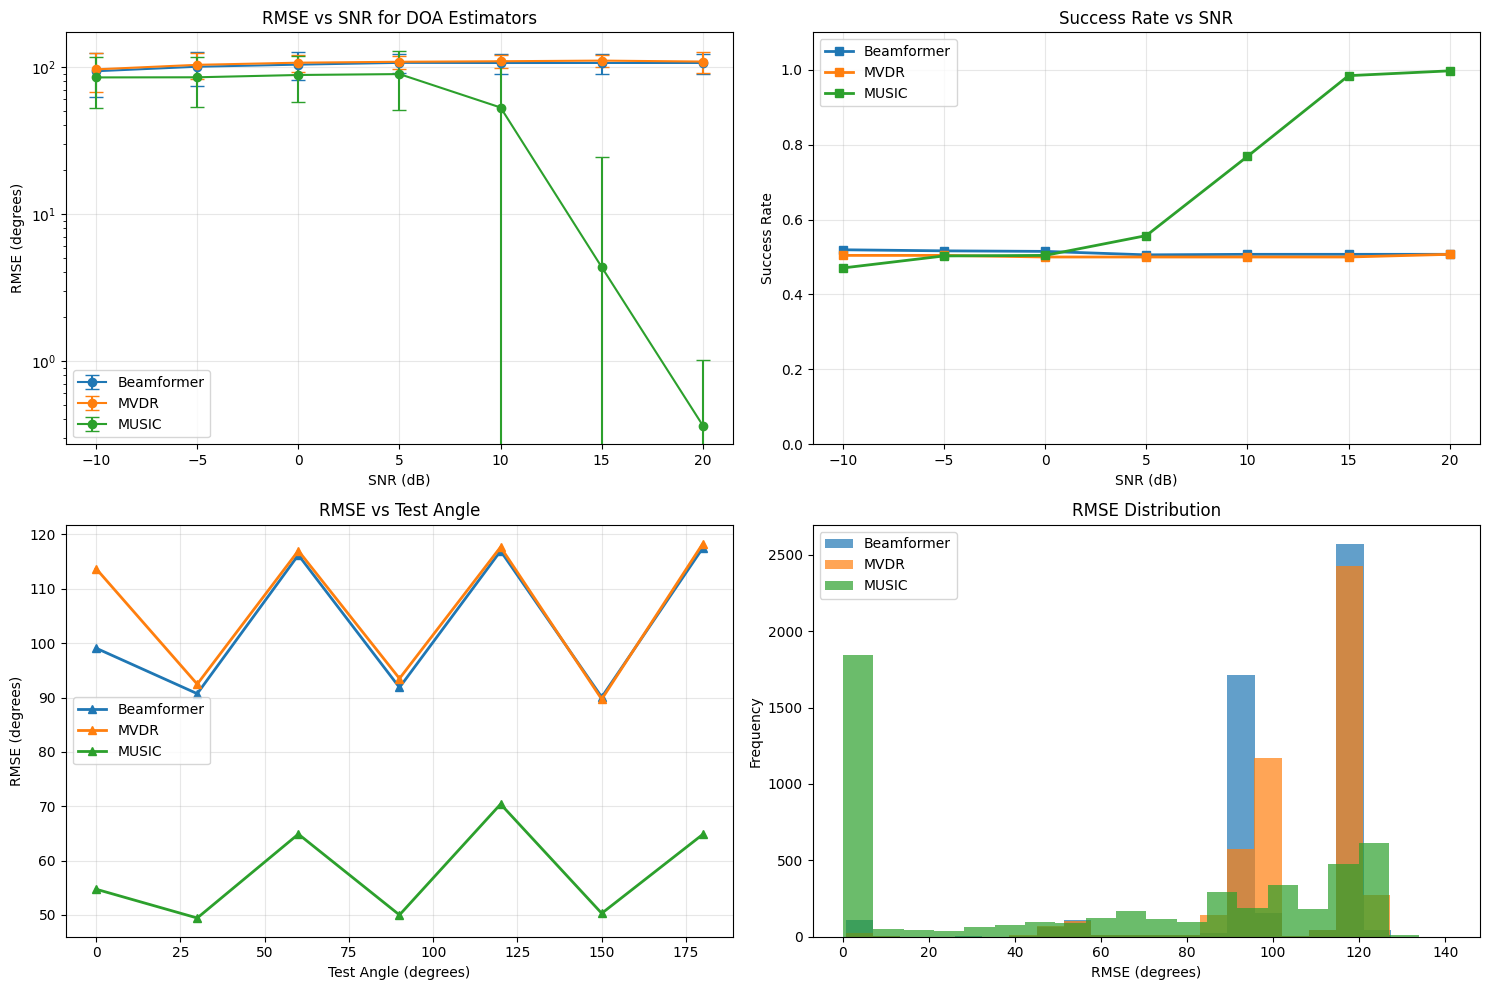

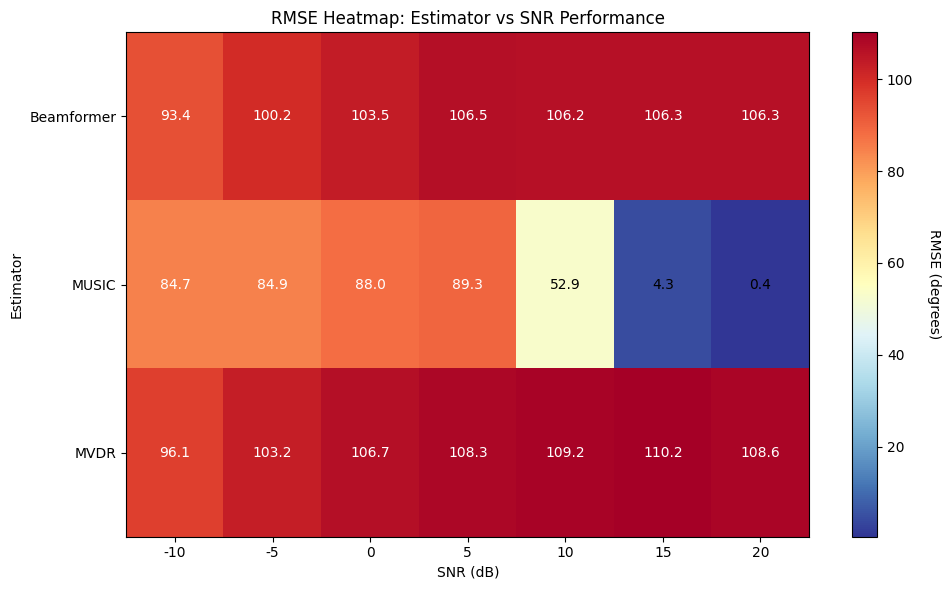

📊 Visualization complete! Check the plots above for detailed performance analysis.


In [22]:
# Step 9: Visualization of Results
if 'combined_results' in locals() and not combined_results.empty:
    
    # Set up plotting style
    plt.style.use('default')
    plt.rcParams['figure.figsize'] = (12, 8)
    
    # 1. RMSE vs SNR Plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: RMSE vs SNR for all estimators
    ax1 = axes[0, 0]
    for estimator in combined_results['estimator'].unique():
        estimator_data = combined_results[combined_results['estimator'] == estimator]
        rmse_by_snr = estimator_data.groupby('snr_db')['rmse'].agg(['mean', 'std'])
        
        ax1.errorbar(rmse_by_snr.index, rmse_by_snr['mean'], 
                    yerr=rmse_by_snr['std'], marker='o', label=estimator, capsize=5)
    
    ax1.set_xlabel('SNR (dB)')
    ax1.set_ylabel('RMSE (degrees)')
    ax1.set_title('RMSE vs SNR for DOA Estimators')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    
    # Plot 2: Success Rate vs SNR
    ax2 = axes[0, 1]
    for estimator in combined_results['estimator'].unique():
        estimator_data = combined_results[combined_results['estimator'] == estimator]
        success_by_snr = estimator_data.groupby('snr_db')['success_rate'].mean()
        
        ax2.plot(success_by_snr.index, success_by_snr.values, 
                marker='s', label=estimator, linewidth=2)
    
    ax2.set_xlabel('SNR (dB)')
    ax2.set_ylabel('Success Rate')
    ax2.set_title('Success Rate vs SNR')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.1)
    
    # Plot 3: Performance by Angle
    ax3 = axes[1, 0]
    for estimator in combined_results['estimator'].unique():
        estimator_data = combined_results[combined_results['estimator'] == estimator]
        rmse_by_angle = estimator_data.groupby('test_angle')['rmse'].mean()
        
        ax3.plot(rmse_by_angle.index, rmse_by_angle.values, 
                marker='^', label=estimator, linewidth=2)
    
    ax3.set_xlabel('Test Angle (degrees)')
    ax3.set_ylabel('RMSE (degrees)')
    ax3.set_title('RMSE vs Test Angle')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Scenario Comparison (if multiple scenarios)
    ax4 = axes[1, 1]
    if combined_results['scenario'].nunique() > 1:
        scenario_rmse = combined_results.groupby(['scenario', 'estimator'])['rmse'].mean().unstack()
        scenario_rmse.plot(kind='bar', ax=ax4, rot=45)
        ax4.set_xlabel('Scenario')
        ax4.set_ylabel('RMSE (degrees)')
        ax4.set_title('RMSE by Scenario')
        ax4.legend(title='Estimator')
    else:
        # Show distribution of errors for single scenario
        for estimator in combined_results['estimator'].unique():
            estimator_data = combined_results[combined_results['estimator'] == estimator]
            ax4.hist(estimator_data['rmse'].dropna(), alpha=0.7, label=estimator, bins=20)
        ax4.set_xlabel('RMSE (degrees)')
        ax4.set_ylabel('Frequency')
        ax4.set_title('RMSE Distribution')
        ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 2. Detailed Heatmap for RMSE vs SNR and Estimator
    if len(combined_results['snr_db'].unique()) > 1:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Create pivot table for heatmap
        heatmap_data = combined_results.groupby(['estimator', 'snr_db'])['rmse'].mean().unstack()
        
        # Create heatmap
        im = ax.imshow(heatmap_data.values, cmap='RdYlBu_r', aspect='auto')
        
        # Set ticks and labels
        ax.set_xticks(range(len(heatmap_data.columns)))
        ax.set_xticklabels(heatmap_data.columns)
        ax.set_yticks(range(len(heatmap_data.index)))
        ax.set_yticklabels(heatmap_data.index)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('RMSE (degrees)', rotation=270, labelpad=20)
        
        # Add text annotations
        for i in range(len(heatmap_data.index)):
            for j in range(len(heatmap_data.columns)):
                value = heatmap_data.iloc[i, j]
                if not np.isnan(value):
                    ax.text(j, i, f'{value:.1f}', ha='center', va='center', 
                           color='white' if value > heatmap_data.values.max()/2 else 'black')
        
        ax.set_xlabel('SNR (dB)')
        ax.set_ylabel('Estimator')
        ax.set_title('RMSE Heatmap: Estimator vs SNR Performance')
        
        plt.tight_layout()
        plt.show()
    
    print("📊 Visualization complete! Check the plots above for detailed performance analysis.")
    
else:
    print("⚠️  No results available for plotting. Please run the Monte Carlo tests first.")


# Monte Carlo DOA Estimation Benchmark - Usage Guide

## 🎯 How to Use This Benchmark

### Step-by-Step Instructions:

1. **Run Cell 1**: Import modules and set up scenarios ✅
2. **Run Cell 2**: Configure array model ✅  
3. **Run Cell 3**: Initialize DOA estimators ✅
4. **Run Cell 4**: Create Monte Carlo testing function ✅
5. **Run Cell 5**: Configure test parameters ✅
6. **Run Cell 6**: Quick test (recommended first) ✅
7. **Run Cell 7**: Full Monte Carlo tests (modify `scenarios_to_test` list)
8. **Run Cell 8**: Analyze results
9. **Run Cell 9**: Visualize performance

### 🔧 Customization Options:

**Test Parameters** (modify in Cell 5):
- `test_angles`: List of angles to test (degrees)
- `snr_range`: List of SNR values to test (dB) 
- `num_examples`: Monte Carlo examples per combination

**Scenarios** (modify in Cell 7):
- Comment/uncomment scenarios in `scenarios_to_test` list
- Start with `'main_only'` for fastest results
- Add interference/multipath scenarios as needed

**Array Configuration** (modify in Cell 2):
- `array_type`: 'linear', 'circular', 'triangular'
- `num_elements`: Number of array elements
- `enable_gain_phase_errors`: Array imperfections

### ⏱️ Expected Runtime:
- **Quick test**: ~10 seconds
- **Single scenario**: 5-15 minutes (depending on complexity)
- **All scenarios**: 30-90 minutes (depending on hardware)

### 📊 Key Metrics:
- **RMSE**: Root Mean Square Error in degrees
- **Success Rate**: Fraction of successful estimations  
- **MAE**: Mean Absolute Error in degrees

### 💡 Tips:
- Start with quick test to verify functionality
- Test one scenario at a time initially
- Monitor memory usage for large test sets
- Save results with `combined_results.to_csv('results.csv')` if needed
